In [11]:
# CROSS-CULTURAL RADAR CHART FOR IEEE ACADEMIC PAPER
# Publication-ready spider chart comparing emotional footprints across languages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Target decade (change here to swap: 1920, 1850, etc.)
target_decade = 1940
FIG_NUMBER = 'X'

# Define the 11 emotion categories (lowercase for column matching)
EMOTION_COLUMNS = ['anger', 'contempt', 'disgust', 'fear', 'frustration',
                   'gratitude', 'joy', 'love', 'neutral', 'sadness', 'surprise']

# Display labels (capitalized for academic presentation)
EMOTION_LABELS = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Frustration',
                'Gratitude', 'Joy', 'Love', 'Neutral', 'Sadness', 'Surprise']

# Colorblind-friendly palette for three languages
COLOR_PALETTE = {
    'English': '#1f77b4',   # Vibrant blue
    'Hindi': '#d62728',    # Vibrant red  
    'Tamil': '#2ca02c'    # Vibrant green
}

print("="*60)
print(f"IEEE PUBLICATION-READY RADAR CHART: {target_decade}s")
print("="*60)

IEEE PUBLICATION-READY RADAR CHART: 1940s


In [12]:
# =============================================================================
# 1. DATA PROCESSING
# =============================================================================

# Load all three emotion datasets
english_emotions = pd.read_csv('final_english_emotions.csv')
hindi_emotions = pd.read_csv('final_hindi_emotions.csv')
tamil_emotions = pd.read_csv('final_tamil_emotions.csv')

# Add Language column to identify source
english_emotions['Language'] = 'English'
hindi_emotions['Language'] = 'Hindi'
tamil_emotions['Language'] = 'Tamil'

# Combine into single master dataframe
master_df = pd.concat([english_emotions, hindi_emotions, tamil_emotions], ignore_index=True)

# Determine time_period column name
time_col = 'time_period' if 'time_period' in master_df.columns else 'decade'

# Normalize time_period values to decade integer
def normalize_decade(val):
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    if len(val_str) >= 4 and val_str[:4].isdigit():
        return int(val_str[:4])
    return None

master_df[time_col] = master_df[time_col].apply(normalize_decade)
master_df = master_df.dropna(subset=[time_col])
master_df[time_col] = master_df[time_col].astype(int)

# Filter to target decade
decade_df = master_df[master_df[time_col] == target_decade].copy()

# Group by Language and calculate mean for all emotion columns
emotion_by_lang = decade_df.groupby('Language')[EMOTION_COLUMNS].mean()

print(f"Documents in {target_decade}s: {len(decade_df)}")
print(f"  - English: {len(decade_df[decade_df['Language'] == 'English'])}")
print(f"  - Hindi: {len(decade_df[decade_df['Language'] == 'Hindi'])}")
print(f"  - Tamil: {len(decade_df[decade_df['Language'] == 'Tamil'])}")
print(f"\nEmotion means by language for {target_decade}s:")
print(emotion_by_lang.round(4).T)

Documents in 1940s: 595
  - English: 360
  - Hindi: 150
  - Tamil: 85

Emotion means by language for 1940s:
Language     English   Hindi   Tamil
anger         0.0623  0.0301  0.0330
contempt      0.0499  0.0953  0.2342
disgust       0.0363  0.0077  0.0116
fear          0.0943  0.0166  0.0037
frustration   0.0125  0.0146  0.0130
gratitude     0.0075  0.0241  0.0123
joy           0.0459  0.0243  0.0071
love          0.0525  0.0233  0.0179
neutral       0.5510  0.8584  0.8150
sadness       0.0232  0.0098  0.0110
surprise      0.1199  0.0347  0.0413


In [13]:
# =============================================================================
# 2. RADAR CHART MATHEMATICS
# =============================================================================

# Extract emotion categories as labels
categories = EMOTION_LABELS
N = len(categories)

# Calculate angle for each axis
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Append the first value to the end to close the polygon
angles_closed = angles + angles[:1]

# Get values for each language and close the polygon
english_values = emotion_by_lang.loc['English'].values.tolist()
english_values_closed = english_values + english_values[:1]

hindi_values = emotion_by_lang.loc['Hindi'].values.tolist()
hindi_values_closed = hindi_values + hindi_values[:1]

tamil_values = emotion_by_lang.loc['Tamil'].values.tolist()
tamil_values_closed = tamil_values + tamil_values[:1]

print(f"Categories ({N}): {categories}")
print(f"Angles (radians): {[round(a, 4) for a in angles]}")
print(f"\nEnglish values (closed): {[round(v, 4) for v in english_values_closed]}")
print(f"Hindi values (closed): {[round(v, 4) for v in hindi_values_closed]}")
print(f"Tamil values (closed): {[round(v, 4) for v in tamil_values_closed]}")

Categories (11): ['Anger', 'Contempt', 'Disgust', 'Fear', 'Frustration', 'Gratitude', 'Joy', 'Love', 'Neutral', 'Sadness', 'Surprise']
Angles (radians): [0.0, 0.5712, 1.1424, 1.7136, 2.2848, 2.856, 3.4272, 3.9984, 4.5696, 5.1408, 5.712]

English values (closed): [0.0623, 0.0499, 0.0363, 0.0943, 0.0125, 0.0075, 0.0459, 0.0525, 0.551, 0.0232, 0.1199, 0.0623]
Hindi values (closed): [0.0301, 0.0953, 0.0077, 0.0166, 0.0146, 0.0241, 0.0243, 0.0233, 0.8584, 0.0098, 0.0347, 0.0301]
Tamil values (closed): [0.033, 0.2342, 0.0116, 0.0037, 0.013, 0.0123, 0.0071, 0.0179, 0.815, 0.011, 0.0413, 0.033]



Graph saved as: radar_chart_1940s.png
Resolution: 300 DPI (publication-ready)


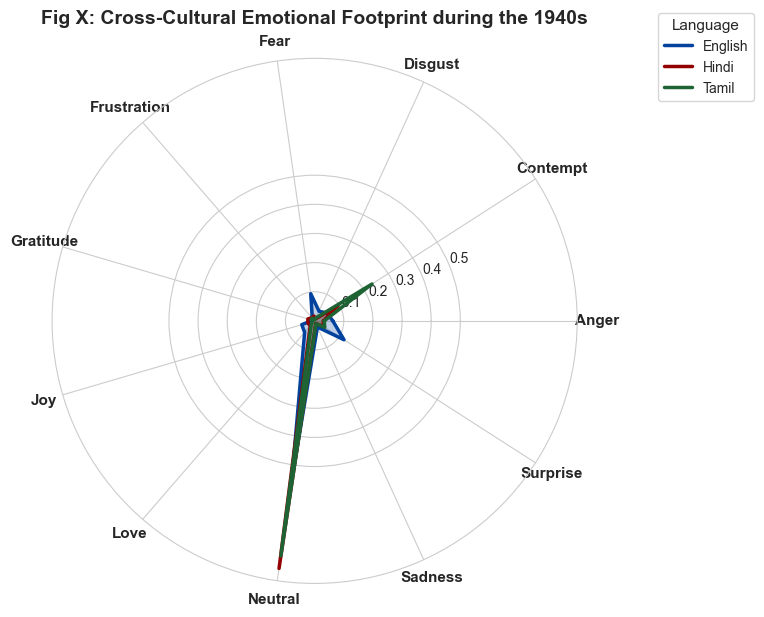

In [14]:
# =============================================================================
# 3. PLOTTING THE RADAR CHART
# =============================================================================

# Set seaborn style for academic aesthetics
sns.set_style('whitegrid')

# Initialize figure with polar projection
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each language
for language, values, color in [
    ('English', english_values_closed, COLOR_PALETTE['English']),
    ('Hindi', hindi_values_closed, COLOR_PALETTE['Hindi']),
    ('Tamil', tamil_values_closed, COLOR_PALETTE['Tamil'])
]:
    # Plot the line
    ax.plot(angles_closed, values, color=color, linewidth=2.5, label=language)
    # Fill the area underneath with transparency
    ax.fill(angles_closed, values, color=color, alpha=0.25)

# Set custom emotion labels around the perimeter
ax.set_thetagrids(np.degrees(angles), categories, fontsize=11, fontweight='bold')

# Set title
ax.set_title(
    f'Fig {FIG_NUMBER}: Cross-Cultural Emotional Footprint during the {target_decade}s',
    fontsize=14, fontweight='bold', pad=25
)

# Place legend outside the top right of the polar plot
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10, title='Language', title_fontsize=11)

# Adjust the radial axis to start from 0 and show proper scale
ax.set_ylim(0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.5)

# Use radial grid labels
ax.set_rticks([0.1, 0.2, 0.3, 0.4, 0.5])

# Tight layout
plt.tight_layout()

# Save as high-resolution PNG (300 DPI)
output_filename = f'radar_chart_{target_decade}s.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"\nGraph saved as: {output_filename}")
print(f"Resolution: 300 DPI (publication-ready)")

# Display
plt.show()

In [15]:
# =============================================================================
# 4. SUMMARY STATISTICS
# =============================================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

# Show dominant emotions by language
for language in ['English', 'Hindi', 'Tamil']:
    lang_data = emotion_by_lang.loc[language]
    sorted_data = lang_data.sort_values(ascending=False)
    print(f"\n{language} ({target_decade}s):")
    for i, (emotion, value) in enumerate(sorted_data.head(3).items()):
        print(f"  {i+1}. {emotion.capitalize()}: {value:.4f}")

# Note on swapping decades
print("\n" + "-"*60)
print("TO SWAP DECADE: Change target_decade variable in [setup] cell")
print("Available decades: 1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960")
print("-"*60)


SUMMARY STATISTICS

English (1940s):
  1. Neutral: 0.5510
  2. Surprise: 0.1199
  3. Fear: 0.0943

Hindi (1940s):
  1. Neutral: 0.8584
  2. Contempt: 0.0953
  3. Surprise: 0.0347

Tamil (1940s):
  1. Neutral: 0.8150
  2. Contempt: 0.2342
  3. Surprise: 0.0413

------------------------------------------------------------
TO SWAP DECADE: Change target_decade variable in [setup] cell
Available decades: 1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960
------------------------------------------------------------


In [16]:
# =============================================================================
# TIME-SERIES LINE CHART WITH ROLLING AVERAGE
# =============================================================================
# Cross-Cultural Time-Series for IEEE Academic Paper
# Publication-ready visualization with 3-period rolling average smoothing

# Set target emotion (change here to swap: 'Joy', 'Fear', 'Anger', etc.)
target_emotion = 'Joy'
FIG_NUMBER = 'X'

# Valid decades for the time series
VALID_DECADES = [1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960]

# Colorblind-friendly palette for three languages
COLOR_PALETTE = {
    'English': '#1f77b4',   # Vibrant blue
    'Hindi': '#d62728',    # Vibrant red  
    'Tamil': '#2ca02c'    # Vibrant green
}

# Define markers for each language
MARKERS = {
    'English': 'o',  # Circle
    'Hindi': '^',   # Triangle up
    'Tamil': 's'    # Square
}

print("="*60)
print(f"TIME-SERIES CHART: {target_emotion.upper()} TRAJECTORY (1810-1960)")
print("="*60)

TIME-SERIES CHART: JOY TRAJECTORY (1810-1960)


In [17]:
# =============================================================================
# 1. DATA PROCESSING & SMOOTHING
# =============================================================================

# Load all three emotion datasets
english_emotions = pd.read_csv('final_english_emotions.csv')
hindi_emotions = pd.read_csv('final_hindi_emotions.csv')
tamil_emotions = pd.read_csv('final_tamil_emotions.csv')

# Add Language column to identify source
english_emotions['Language'] = 'English'
hindi_emotions['Language'] = 'Hindi'
tamil_emotions['Language'] = 'Tamil'

# Combine into single master dataframe
master_df = pd.concat([english_emotions, hindi_emotions, tamil_emotions], ignore_index=True)

# Determine time_period column name
time_col = 'time_period' if 'time_period' in master_df.columns else 'decade'

# Normalize time_period values to decade integer
def normalize_decade(val):
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    if len(val_str) >= 4 and val_str[:4].isdigit():
        return int(val_str[:4])
    return None

master_df[time_col] = master_df[time_col].apply(normalize_decade)
master_df = master_df.dropna(subset=[time_col])
master_df[time_col] = master_df[time_col].astype(int)

# Get target column (lowercase for matching)
target_col = target_emotion.lower()

print(f"Total documents loaded: {len(master_df)}")
print(f"  - English: {len(english_emotions)}")
print(f"  - Hindi: {len(hindi_emotions)}")
print(f"  - Tamil: {len(tamil_emotions)}")
print(f"\nTarget emotion: {target_emotion}")

Total documents loaded: 32563
  - English: 24403
  - Hindi: 4705
  - Tamil: 3455

Target emotion: Joy


In [18]:
# =============================================================================
# 2. AGGREGATE, PIVOT & APPLY ROLLING AVERAGE
# =============================================================================

# Filter to valid decades (1810 to 1960)
ts_df = master_df[master_df[time_col].isin(VALID_DECADES)].copy()

# Group by Language and time_period, calculate mean for target_emotion
grouped = ts_df.groupby(['Language', time_col])[target_col].mean().reset_index()
grouped.columns = ['Language', 'time_period', 'Mean Intensity']

# Pivot: time_period as index, Language as columns
pivot_df = grouped.pivot(index='time_period', columns='Language', values='Mean Intensity')

# Sort chronologically
pivot_df = pivot_df.sort_index()

# Apply 3-period rolling average (center=True for smoothing)
smoothed_df = pivot_df.rolling(window=3, min_periods=1, center=True).mean()

# Melt back to long format for Seaborn
smoothed_long = smoothed_df.reset_index().melt(
    id_vars=['time_period'],
    var_name='Language',
    value_name='Smoothed Mean Intensity'
)

print(f"\nSmoothed data for '{target_emotion}' (3-period rolling average):")
print(smoothed_long.round(4).to_string(index=False))


Smoothed data for 'Joy' (3-period rolling average):
 time_period Language  Smoothed Mean Intensity
        1810  English                   0.0738
        1820  English                   0.0674
        1830  English                   0.0668
        1840  English                   0.0578
        1850  English                   0.0626
        1860  English                   0.0559
        1870  English                   0.0546
        1880  English                   0.0434
        1890  English                   0.0434
        1900  English                   0.0421
        1910  English                   0.0473
        1920  English                   0.0430
        1930  English                   0.0448
        1940  English                   0.0394
        1950  English                   0.0570
        1960  English                   0.0625
        1810    Hindi                   0.0315
        1820    Hindi                   0.0284
        1830    Hindi                   0.0313
       


Graph saved as: smoothed_emotion_timeseries.png
Resolution: 300 DPI (publication-ready)


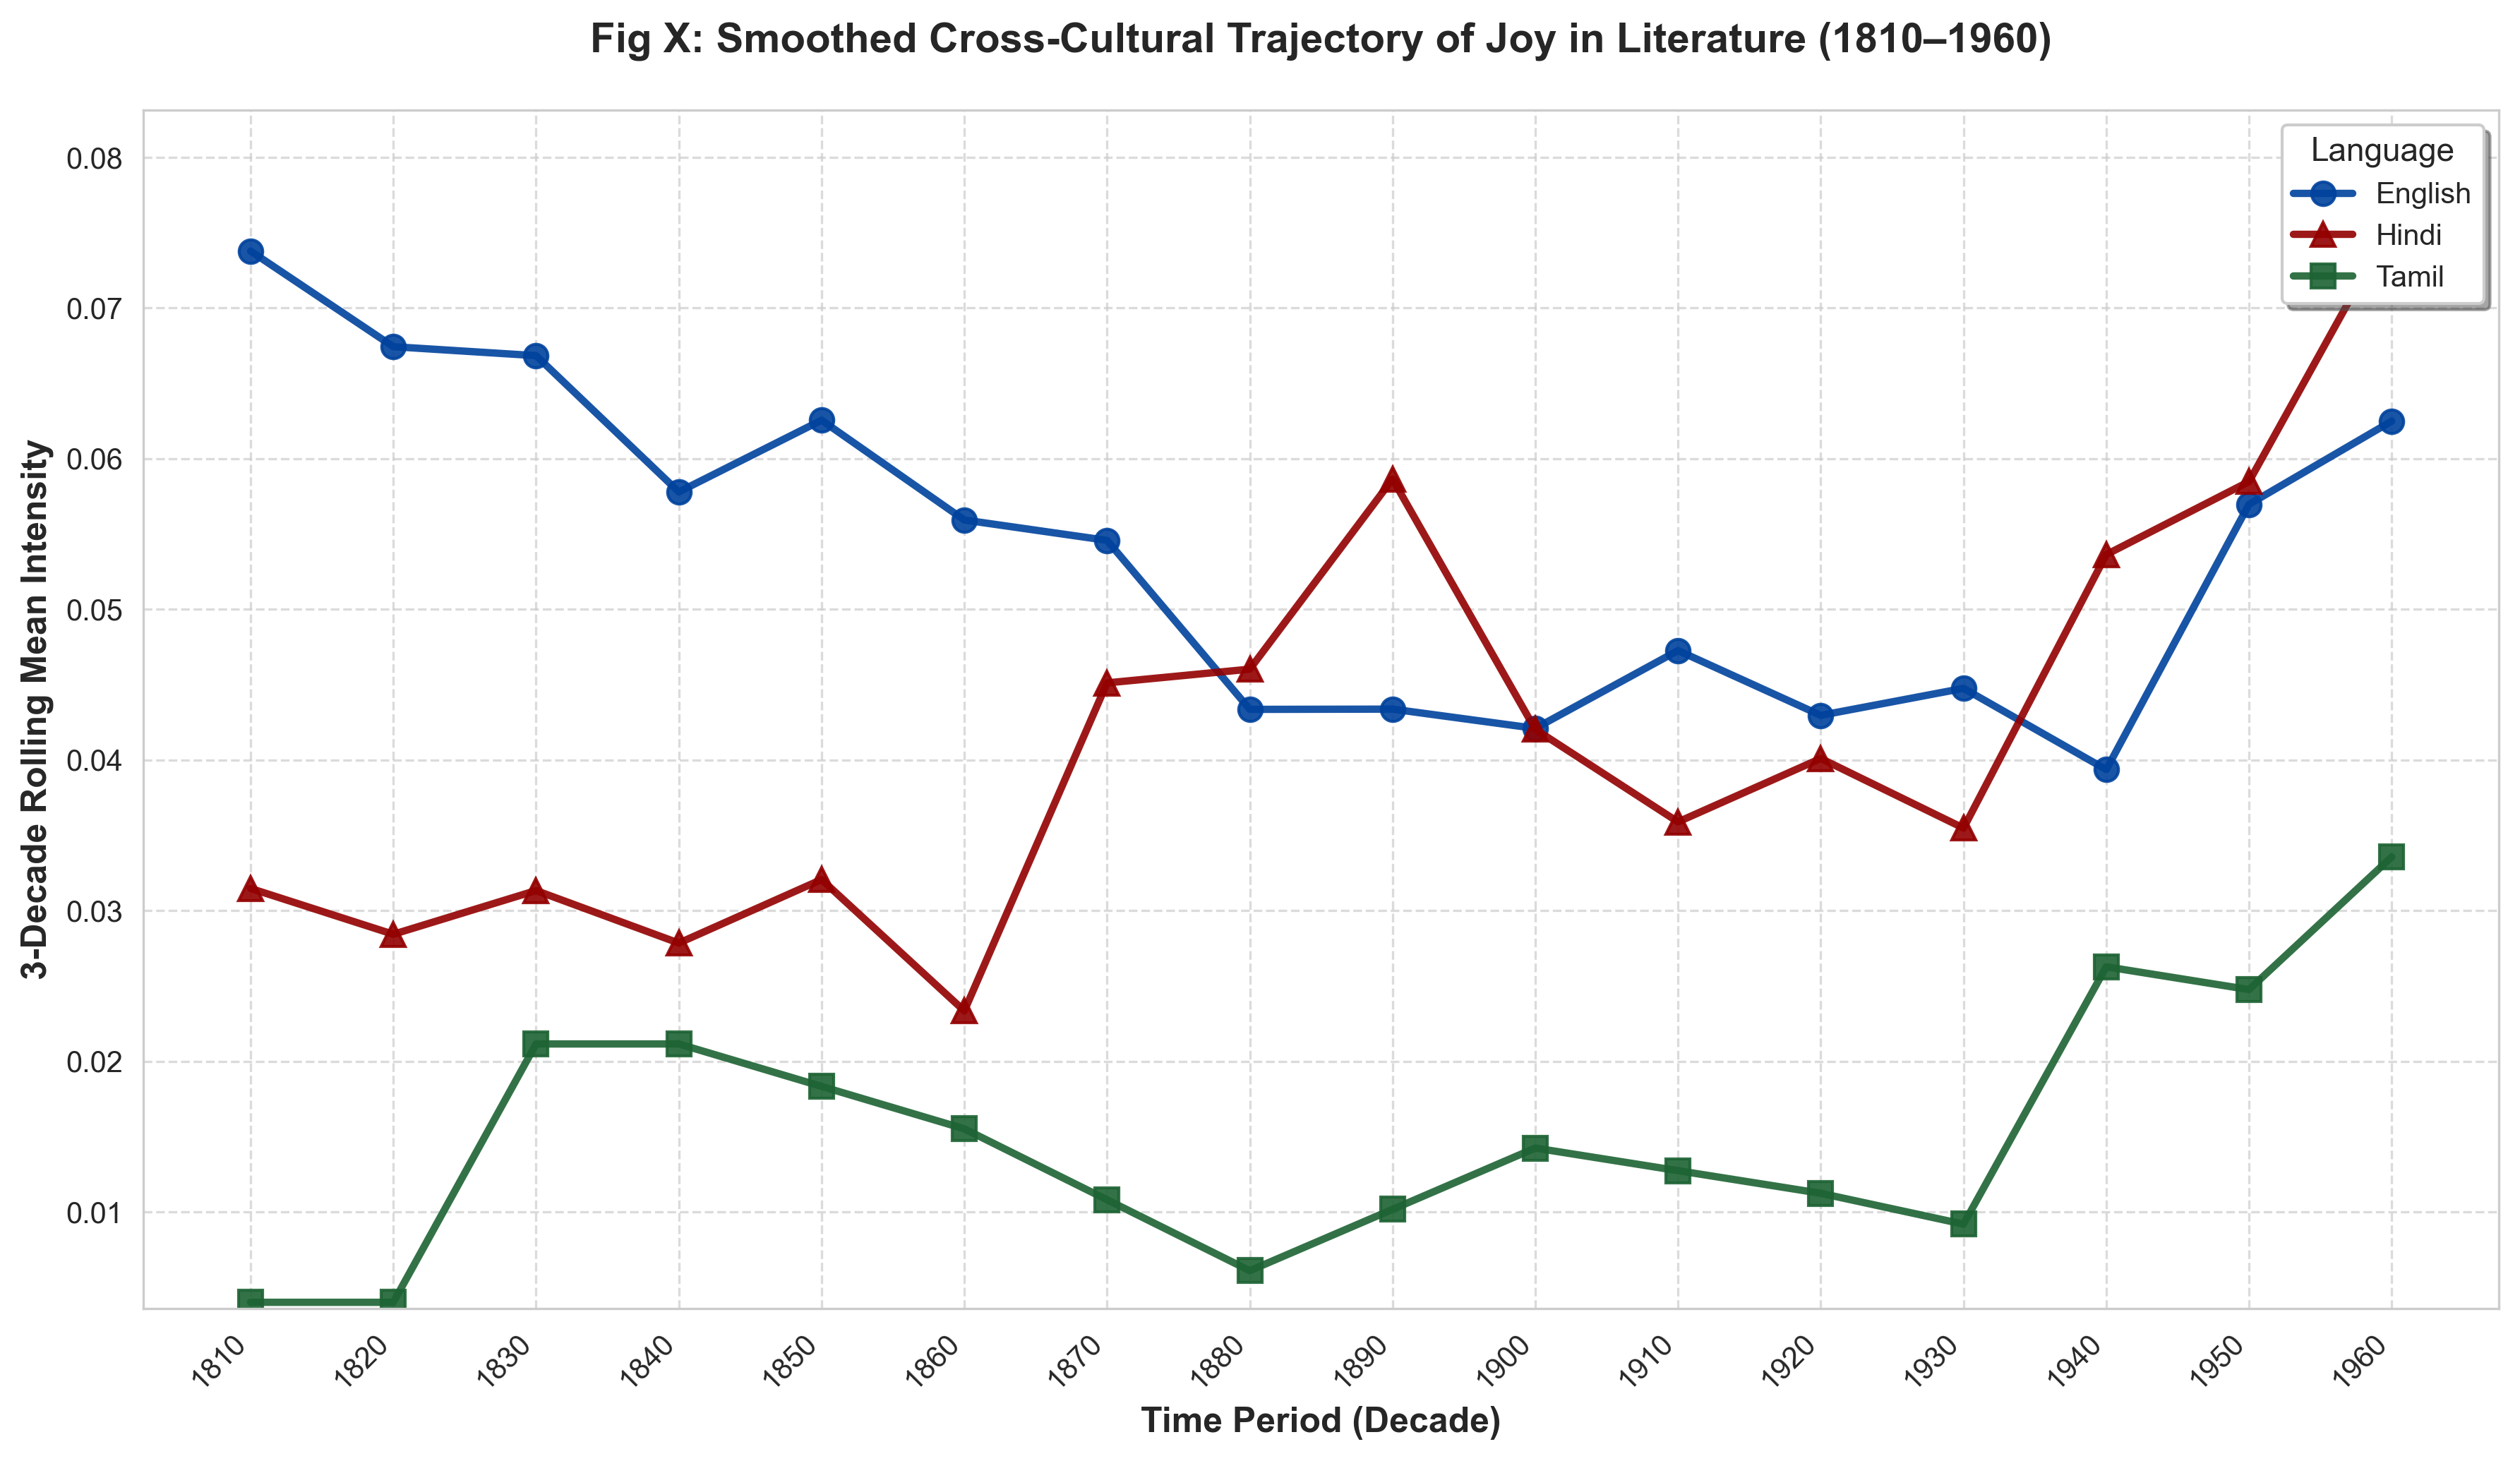

In [19]:
# =============================================================================
# 3. PLOTTING THE TIME-SERIES GRAPH
# =============================================================================

# Set seaborn style for academic aesthetics
sns.set_style('whitegrid')

# Create figure
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Plot each language as distinct line with markers
for language in ['English', 'Hindi', 'Tamil']:
    lang_data = smoothed_long[smoothed_long['Language'] == language].sort_values('time_period')
    ax.plot(
        lang_data['time_period'],
        lang_data['Smoothed Mean Intensity'],
        marker=MARKERS[language],
        color=COLOR_PALETTE[language],
        linewidth=2.5,
        markersize=8,
        label=language,
        alpha=0.9
    )

# Set title (IEEE format)
ax.set_title(
    f'Fig {FIG_NUMBER}: Smoothed Cross-Cultural Trajectory of {target_emotion} in Literature (1810–1960)',
    fontsize=14, fontweight='bold', pad=20
)

# Set axis labels
ax.set_xlabel('Time Period (Decade)', fontsize=12, fontweight='bold')
ax.set_ylabel('3-Decade Rolling Mean Intensity', fontsize=12, fontweight='bold')

# Set x-axis ticks to show every decade
ax.set_xticks(VALID_DECADES)
ax.set_xticklabels(VALID_DECADES, rotation=45, ha='right')

# Configure legend
ax.legend(title='Language', loc='upper right', fontsize=10, title_fontsize=11,
         frameon=True, fancybox=True, shadow=True)

# Add gridlines
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Set y-axis limits with some padding
y_max = smoothed_long['Smoothed Mean Intensity'].max() * 1.1
y_min = max(0, smoothed_long['Smoothed Mean Intensity'].min() * 0.9)
ax.set_ylim(y_min, y_max)

# Tight layout
plt.tight_layout()

# Save as high-resolution PNG (300 DPI)
output_filename = 'smoothed_emotion_timeseries.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"\nGraph saved as: {output_filename}")
print(f"Resolution: 300 DPI (publication-ready)")

# Display
plt.show()

In [20]:
# =============================================================================
# 4. SUMMARY STATISTICS
# =============================================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

# Show summary by language
for language in ['English', 'Hindi', 'Tamil']:
    lang_data = smoothed_long[smoothed_long['Language'] == language]
    print(f"\n{language}:")
    print(f"  Mean: {lang_data['Smoothed Mean Intensity'].mean():.4f}")
    print(f"  Max: {lang_data['Smoothed Mean Intensity'].max():.4f} (Decade: {lang_data.loc[lang_data['Smoothed Mean Intensity'].idxmax(), 'time_period']})")
    print(f"  Min: {lang_data['Smoothed Mean Intensity'].min():.4f} (Decade: {lang_data.loc[lang_data['Smoothed Mean Intensity'].idxmin(), 'time_period']})")

# Note on swapping emotions
print("\n" + "-"*60)
print("TO SWAP EMOTION: Change target_emotion variable in [ts_setup] cell")
print("Available emotions: ['Joy', 'Fear', 'Anger', 'Sadness', 'Love', 'Contempt', etc.]")
print("-"*60)


SUMMARY STATISTICS

English:
  Mean: 0.0539
  Max: 0.0738 (Decade: 1810)
  Min: 0.0394 (Decade: 1940)

Hindi:
  Mean: 0.0416
  Max: 0.0756 (Decade: 1960)
  Min: 0.0234 (Decade: 1860)

Tamil:
  Mean: 0.0152
  Max: 0.0336 (Decade: 1960)
  Min: 0.0040 (Decade: 1810)

------------------------------------------------------------
TO SWAP EMOTION: Change target_emotion variable in [ts_setup] cell
Available emotions: ['Joy', 'Fear', 'Anger', 'Sadness', 'Love', 'Contempt', etc.]
------------------------------------------------------------
